# Compare RL policy with row-by-row policy
This script compares a learned Reinforcement Learning (RL) policy with a row-by-row strategy generated by `Fields2Cover`.

In [ ]:
from __future__ import annotations

from pathlib import Path
from typing import TYPE_CHECKING

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from tqdm import tqdm_notebook as tqdm
from moviepy.editor import ImageSequenceClip

from pygame import Surface
from pygame.surfarray import array3d

from drone_grid_env.envs.drone_grid_env import DroneGridEnv
from drone_grid_env.utils import HidePrinting
from sb3_custom.custom_dqn_algorithm import CustomDQN
from sb3_custom.fields2cover_algorithm import Fields2CoverAlgorithm

if TYPE_CHECKING:
    from typing import Any

    from stable_baselines3.common.base_class import BaseAlgorithm

    from numpy.typing import NDArray

    from gymnasium import Env

%matplotlib inline

# Create output folder
FIGURES_FOLDER = Path().resolve() / "figures"
FIGURES_FOLDER.mkdir(exist_ok=True)

Set the network weights and output file:

In [2]:
ENV_CONFIG_FILE = Path("experiments/stopping_criteria/env_config_coverage_75.yaml")
WEIGHTS_FILE = Path("training/stopping_criteria_coverage_75_last.pt")

assert all(f.is_file() for f in (ENV_CONFIG_FILE, WEIGHTS_FILE)), "Not all files are available"

Create a function that collects frames using a policy:

In [3]:
def collect_episode_data(algorithm: BaseAlgorithm, env: Env, seed: int = 0) -> tuple[list[NDArray[np.uint8]] | dict[str, Any]]:
    frames = []
    obs, info = env.reset(seed=seed)
    terminated = False
    truncated = False

    while not (terminated or truncated):
        obs_unsqueezed = {k: np.expand_dims(v, axis=0) for k, v in obs.items()} if isinstance(obs, dict) else np.expand_dims(obs, axis=0)
        prediction = algorithm.predict(obs_unsqueezed)
        actions = prediction[0]

        obs, _, terminated, truncated, info = env.step(actions[0])
        frames.append(env.render())

    return frames, info

Create function that creates an image of the path:

In [4]:
def get_flight_path_image(env: DroneGridEnv) -> NDArray[np.uint8]:
    env.rendering.config.world_image_padding = 0

    surface = Surface((1024, 1024))
    env.rendering.world_to_surface(surface)
    env.rendering.classified_pixels_to_surface(surface)
    env.rendering.flight_path_to_surface(surface)
    env.rendering.drone_to_surface(surface)
    env.rendering.fov_to_surface(surface)
    return array3d(surface)

Run episodes for all agents:

In [5]:
env = DroneGridEnv(config_file=ENV_CONFIG_FILE, render_mode="rgb_array_headless")

# Define methods
with HidePrinting():
    dqn = CustomDQN.load(WEIGHTS_FILE, env=env)
    rbr = Fields2CoverAlgorithm.load(None, env=env)
    # greedy = GreedyAlgorithm.load(None, env=env)

methods = [dqn, rbr]  # , greedy]

frames = []
infos = []
flight_path_images = []

for method in tqdm(methods):
    m_frames, m_info = collect_episode_data(method, env, seed=10)
    m_flight_path_image = get_flight_path_image(env)
    frames.append(m_frames)
    infos.append(m_info)
    flight_path_images.append(m_flight_path_image)

env.close()

  0%|          | 0/2 [00:00<?, ?it/s]

Show the results:

In [9]:
def _generate_row(infos: list[dict[str, Any]], label: str, key: str) -> list[str, int | float, int | float]:
    row = [label]
    row.extend([round(info[key], 3) if isinstance(info[key], float) else info[key] for info in infos])
    return row


header = [""] + [type(method).__name__ for method in methods]
data = [
    _generate_row(infos, "Steps", "stp"),
    _generate_row(infos, "Reward", "rew"),
    _generate_row(infos, "Remaining battery", "bat"),
    _generate_row(infos, "Percentage found objects", "cwp"),
    _generate_row(infos, "Percentage covered", "cov"),
    _generate_row(infos, "Path length", "pl"),
]

df = pd.DataFrame(data, columns=header)

df

,,CustomDQN,Fields2CoverAlgorithm
0,Steps,375.000,194.000
1,Reward,-12.127,117.925
2,Remaining battery,-0.000,36.200
3,Percentage found objects,1.000,0.955
4,Percentage covered,0.461,0.751
5,Path length,375.000,194.000


Show the flight path:

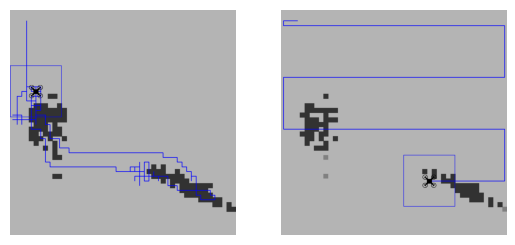

In [10]:
fig, axs = plt.subplots(1, len(flight_path_images))

for ax, img in zip(axs, flight_path_images):
    ax.imshow(np.transpose(img, (1, 0, 2)))
    ax.axis("off")

plt.show()

Generate a GIF image:

In [11]:
def _fix_length(l: list[Any], length: int):
    while len(l) < length:
        l.append(l[-1])


for frame in frames:
    _fix_length(frame, max([len(m_frames) for m_frames in frames]))

frame_buffer = []
for frame in zip(*frames):
    frame_buffer.append(np.hstack(frame))

clip = ImageSequenceClip(frame_buffer, fps=20)
clip.write_gif(FIGURES_FOLDER / "comparison.gif", fps=20, verbose=False, logger=None)

clip.ipython_display(width=1200)

Moviepy - Building video __temp__.mp4.
Moviepy - Writing video __temp__.mp4



Moviepy - Done !
Moviepy - video ready __temp__.mp4
